# Анализ эмбеддингов: кластеризация, semantic anchors, anchor words

**Проект**: CreateCompleteLang  
**Вход**: `word_vectors.npy` + `meta.json` (из пайплайна `build_embeddings`)  

## Содержание
1. Загрузка данных и базовая статистика
2. Предобработка: нормализация, фильтрация нулевых норм
3. Кластеризация
   - 3a. Алгоритм Вишарта (плотностная кластеризация через kNN + DSU)
   - 3b. DBSCAN (baseline для сравнения)
4. Валидация кластеризации (внутренние меры)
5. Нахождение semantic anchors (опорных векторов) для каждого кластера
6. Anchor Words — извлечение anchor-слов и тематическая интерпретация
7. Визуализация (PCA 2D + кластеры + anchors)

---
## 0. Конфигурация и импорты

In [1]:
import json
from pathlib import Path
from csv import DictReader
from dataclasses import dataclass, field

import numpy as np
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib

# Шрифт с поддержкой Devanagari (Marathi)
matplotlib.rcParams['font.family'] = ['Kohinoor Devanagari', 'sans-serif']

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

In [ ]:
@dataclass
class Config:
    """Все параметры эксперимента в одном месте."""
    # --- Пути ---
    embedding_dir: Path = Path("/Users/ppers/scientific_work/create-complete-lang/data/artifacts/embeddings/stanza_svd2/word_vectors_center_norm")
    vocab_path: Path = Path("/Users/ppers/scientific_work/create-complete-lang/data/artifacts/vocabularies/stanza_v1.tsv")  # 
    
    # --- Вишарт ---
    wishart_k: int = 15           # количество ближайших соседей
    wishart_alpha: float = 1.0    # чувствительность к разрывам (1 = single-linkage)

    # --- DBSCAN ---
    dbscan_eps: float = 0.1
    dbscan_min_samples: int = 5

    # --- Anchor Words ---
    anchor_top_n: int = 10        # сколько anchor-слов на кластер
    anchor_method: str = "medoid" # "centroid" | "medoid" | "pagerank"

    # --- Визуализация ---
    pca_components: int = 2
    max_labels_on_plot: int = 50


cfg = Config()
print(cfg)

Config(embedding_dir=PosixPath('/Users/ppers/scientific_work/create-complete-lang/data/artifacts/archive/english/embeddings'), vocab_path=PosixPath('/Users/ppers/scientific_work/create-complete-lang/data/artifacts/archive/english/vocab.tsv'), wishart_k=15, wishart_alpha=1.0, dbscan_eps=0.1, dbscan_min_samples=5, anchor_top_n=10, anchor_method='medoid', pca_components=2, max_labels_on_plot=50)


---
## 1. Загрузка данных

In [3]:
# --- Загрузка эмбеддингов ---
vectors = np.load(cfg.embedding_dir / "word_vectors.npy")
with open(cfg.embedding_dir / "meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

print(f"Vectors shape: {vectors.shape}  (vocab_size × k)")
print(f"Meta: {json.dumps(meta, indent=2, ensure_ascii=False)}")

Vectors shape: (137035, 300)  (vocab_size × k)
Meta: {
  "schema_version": "0.1.0",
  "method": "svd",
  "k": 300,
  "sigma_power": 0.5,
  "vocab_size": 137035,
  "stats": {
    "vocab_size": 137035,
    "k": 300,
    "sigma_power": 0.5,
    "vector_norm_mean": 0.0738,
    "vector_norm_std": 0.2707,
    "vector_norm_min": 0.0,
    "vector_norm_max": 7.8558,
    "zero_norm_count": 32
  }
}


In [4]:
# --- Загрузка словаря (idx → слово) из TSV ---
# Формат: idx\tlemma\ttf\tdf (со строкой заголовка)
id2word: dict[int, str] = {}
tf_list: list[int] = []
df_list: list[int] = []

with open(cfg.vocab_path, "r", encoding="utf-8") as f:
    reader = DictReader(f, delimiter='\t')
    for row in reader:
        idx = int(row['idx'])
        id2word[idx] = row['lemma']
        tf_list.append(int(row['tf']))
        df_list.append(int(row['df']))

word2id = {v: k for k, v in id2word.items()}
vocab_tf = np.array(tf_list)
vocab_df = np.array(df_list)

print(f"Vocab size: {len(id2word)}")
print(f"Первые 10 слов: {[id2word[i] for i in range(min(10, len(id2word)))]}")
print(f"TF range: [{vocab_tf.min()}, {vocab_tf.max()}], DF range: [{vocab_df.min()}, {vocab_df.max()}]")

Vocab size: 137035
Первые 10 слов: ['have', 'that', 'not', 'with', 'ordinal1', 'as', 'for', 'but', 'do', 'at']
TF range: [2, 3752520], DF range: [2, 9153]


---
## 2. Предобработка

In [5]:
# --- Нормы и фильтрация ---
norms = np.linalg.norm(vectors, axis=1)
zero_mask = norms < 1e-12
print(f"Нулевых векторов: {zero_mask.sum()} из {len(norms)}")

# Маска валидных точек (исключаем нулевые нормы)
valid_mask = ~zero_mask
valid_ids = np.where(valid_mask)[0]
X = vectors[valid_mask]  # рабочая матрица

print(f"Рабочий размер: {X.shape}")

Нулевых векторов: 32 из 137035
Рабочий размер: (137003, 300)


In [6]:
# --- L2-нормализация (для косинусной метрики через евклидово расстояние) ---
X_normed = normalize(X, norm='l2', axis=1)

# После L2-нормализации: ||x|| = 1, и евклидово расстояние
# d(x,y) = sqrt(2 - 2*cos(x,y)), т.е. монотонно связано с cos-расстоянием.

Нормы (после center+norm): mean=0.073784, std=2.71e-01, min=0.001846, max=7.855800


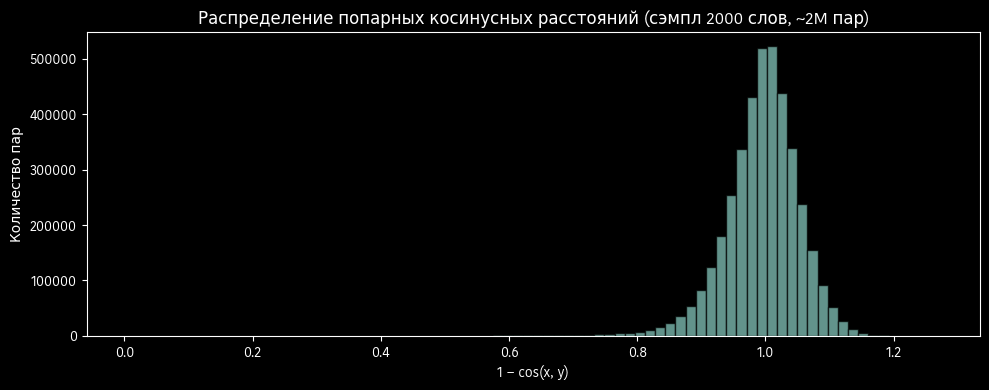

In [7]:
# --- Статистика норм ---
print(f"Нормы (после center+norm): mean={norms[valid_mask].mean():.6f}, "
      f"std={norms[valid_mask].std():.2e}, "
      f"min={norms[valid_mask].min():.6f}, max={norms[valid_mask].max():.6f}")

# --- Гистограмма попарных косинусных расстояний (сэмпл) ---
# ~5–10 сек (cdist на 2000×2000×300)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_normed), size=min(2000, len(X_normed)), replace=False)
sample_dists = cdist(X_normed[sample_idx], X_normed[sample_idx], metric='cosine').ravel()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sample_dists[sample_dists > 0], bins=80, edgecolor='black', alpha=0.7)
ax.set_title("Распределение попарных косинусных расстояний (сэмпл 2000 слов, ~2M пар)")
ax.set_xlabel("1 − cos(x, y)")
ax.set_ylabel("Количество пар")
plt.tight_layout()
plt.show()

---
## 3a. Алгоритм Вишарта

Плотностная кластеризация через kNN-граф и DSU (Disjoint Set Union).  
Алгоритм из отчёта:
1. Для каждой точки считаем $r_i$ — расстояние до $k$-го ближайшего соседа.
2. Формируем события: **ActivateVertex** при $r_i$ и **ActivateEdge** при $t_{ij} = \max(r_i, r_j, d(x_i, x_j)/\alpha)$.
3. Сортируем по радиусу, итеративно строим компоненты связности через DSU.
4. Фиксируем иерархию кластеров $C(r)$ на каждом уровне.

In [24]:
# ============================================================
# DSU (Disjoint Set Union / Union-Find)
# ============================================================

class DSU:
    """Disjoint Set Union с ранговой эвристикой и сжатием путей."""

    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0] * n
        self.size = [1] * n

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]  # path halving
            x = self.parent[x]
        return x

    def union(self, a: int, b: int) -> bool:
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        self.size[ra] += self.size[rb]
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
        return True

    def components(self, active_set: set) -> dict[int, list[int]]:
        """Возвращает {root: [members]} для активных точек."""
        groups: dict[int, list[int]] = {}
        for i in active_set:
            r = self.find(i)
            groups.setdefault(r, []).append(i)
        return groups

In [25]:
# ============================================================
# Wishart clustering
# ============================================================

@dataclass
class WishartSnapshot:
    """Снимок кластеров на конкретном радиусе r."""
    radius: float
    n_active: int
    n_clusters: int
    cluster_sizes: list[int]


@dataclass
class WishartResult:
    """Полный результат работы алгоритма Вишарта."""
    labels: np.ndarray                # labels[i] = cluster_id для точки i (-1 = шум)
    snapshots: list[WishartSnapshot]   # иерархия по уровням r
    knn_dists: np.ndarray             # расстояния до k-го соседа
    knn_indices: np.ndarray           # индексы kNN


def wishart_clustering(
    X: np.ndarray,
    k: int = 15,
    alpha: float = 1.0,
    metric: str = "cosine",
    snapshot_every: int = 0,
    final_radius: float | None = None,
) -> WishartResult:
    """
    Алгоритм Вишарта: плотностная кластеризация через kNN + DSU.

    Parameters
    ----------
    X : (n, d) — нормализованные векторы
    k : порог плотности (кол-во ближайших соседей)
    alpha : >= 1, чувствительность к разрывам
    metric : метрика для NearestNeighbors
    snapshot_every : сохранять снимки каждые N событий (0 = только финал)
    final_radius : остановить на данном радиусе (None = пройти все события)

    Returns
    -------
    WishartResult с labels, snapshots, knn_dists, knn_indices
    """
    n = X.shape[0]

    # 1) kNN
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric, algorithm='auto')
    nn.fit(X)
    dists, indices = nn.kneighbors(X)
    # dists[:,0] = 0 (сам к себе); k-й сосед в dists[:,k]
    knn_dists = dists[:, k]       # r_i
    knn_indices = indices[:, 1:]   # исключаем саму точку

    # 2) Формируем список событий
    ACTIVATE_VERTEX = 0
    ACTIVATE_EDGE = 1
    events = []

    for i in range(n):
        events.append((knn_dists[i], ACTIVATE_VERTEX, i, -1))

    for i in range(n):
        for idx_j in range(knn_indices.shape[1]):
            j = knn_indices[i, idx_j]
            d_ij = dists[i, idx_j + 1]  # +1 потому что мы убрали саму точку из knn_indices
            t_ij = max(knn_dists[i], knn_dists[j], d_ij / alpha)
            events.append((t_ij, ACTIVATE_EDGE, i, j))

    # Сортируем по радиусу (и по типу: вершины раньше рёбер при равном радиусе)
    events.sort(key=lambda e: (e[0], e[1]))

    # 3) DSU-построение
    dsu = DSU(n)
    active = [False] * n
    active_set = set()
    snapshots = []

    for evt_idx, (r, etype, a, b) in enumerate(events):
        if final_radius is not None and r > final_radius:
            break

        if etype == ACTIVATE_VERTEX:
            active[a] = True
            active_set.add(a)
        else:  # ACTIVATE_EDGE
            if active[a] and active[b]:
                dsu.union(a, b)

        # Снимок
        if snapshot_every > 0 and (evt_idx + 1) % snapshot_every == 0:
            groups = dsu.components(active_set)
            snapshots.append(WishartSnapshot(
                radius=r,
                n_active=len(active_set),
                n_clusters=len(groups),
                cluster_sizes=sorted([len(v) for v in groups.values()], reverse=True),
            ))

    # Финальные кластеры
    groups = dsu.components(active_set)
    labels = np.full(n, -1, dtype=int)
    for cluster_id, (root, members) in enumerate(groups.items()):
        for m in members:
            labels[m] = cluster_id

    snapshots.append(WishartSnapshot(
        radius=events[-1][0] if events else 0.0,
        n_active=len(active_set),
        n_clusters=len(groups),
        cluster_sizes=sorted([len(v) for v in groups.values()], reverse=True),
    ))

    return WishartResult(
        labels=labels,
        snapshots=snapshots,
        knn_dists=knn_dists,
        knn_indices=knn_indices,
    )

In [26]:
# --- Запуск Вишарта ---
# ~3–10 мин (kNN brute-force cosine на 112K×300 — основное время;
#             построение и сортировка ~1.8M событий — быстро)
wishart = wishart_clustering(
    X_normed,
    k=cfg.wishart_k,
    alpha=cfg.wishart_alpha,
    metric="cosine",
    snapshot_every=5000,  # для отслеживания иерархии
)

unique_labels = set(wishart.labels)
n_clusters_w = len(unique_labels - {-1})
n_noise_w = (wishart.labels == -1).sum()
print(f"Вишарт: {n_clusters_w} кластеров, {n_noise_w} шумовых точек")
print(f"Топ-10 кластеров по размеру: {wishart.snapshots[-1].cluster_sizes[:10]}")

Вишарт: 1 кластеров, 0 шумовых точек
Топ-10 кластеров по размеру: [112913]


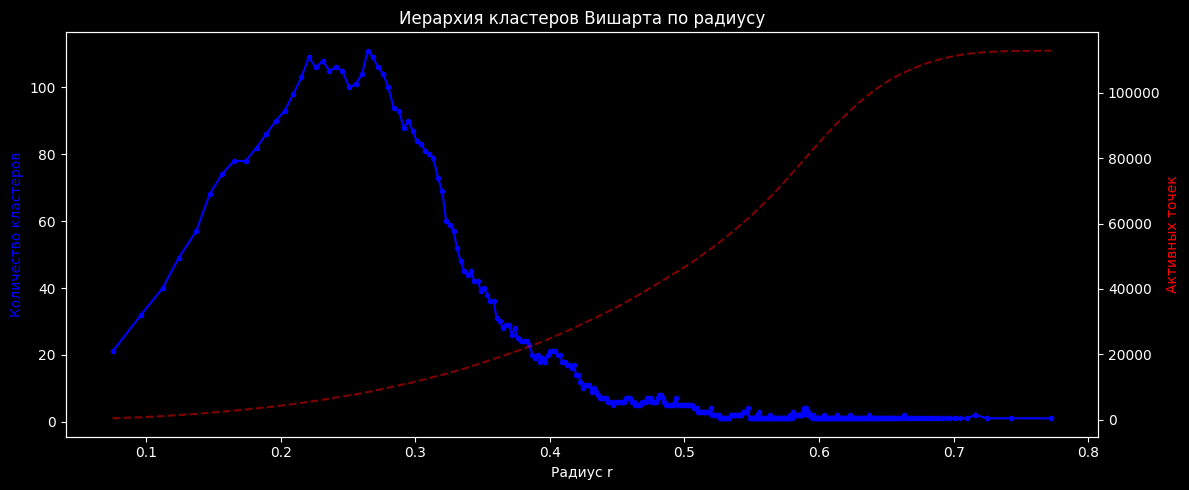

In [28]:
# --- Иерархия: как менялись кластеры по радиусу ---
if len(wishart.snapshots) > 2:
    radii = [s.radius for s in wishart.snapshots]
    n_cls = [s.n_clusters for s in wishart.snapshots]

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(radii, n_cls, 'b-o', markersize=3)
    ax1.set_xlabel('Радиус r')
    ax1.set_ylabel('Количество кластеров', color='b')

    ax2 = ax1.twinx()
    n_act = [s.n_active for s in wishart.snapshots]
    ax2.plot(radii, n_act, 'r--', alpha=0.5)
    ax2.set_ylabel('Активных точек', color='r')

    plt.title('Иерархия кластеров Вишарта по радиусу')
    plt.tight_layout()
    plt.show()

### 3a.1 Выбор оптимального радиуса остановки

Без `final_radius` алгоритм Вишарта проходит **все** события и неизбежно сливает всё в один кластер — это свойство иерархической кластеризации.  
Нужно выбрать радиус $r^*$, на котором кластерная структура наиболее выражена.

**Три эвристики:**
1. **Max-lifetime** — находим радиус, на котором число кластеров стабильно дольше всего (самый длинный "плоский" участок на графике выше).
2. **Max-clusters** — радиус, при котором число кластеров максимально (но это часто слишком ранний момент — много мелких фрагментов).
3. **Silhouette scan** — прогнать несколько кандидатов и выбрать по silhouette score (дороже, но надёжнее).

In [29]:
# ============================================================
# Анализ иерархии снимков — поиск оптимального радиуса
# ============================================================

# n_clusters <= MIN_INTERESTING исключаются из автовыбора:
# n=1 — всё слито, n=2 — почти всегда артефакт (последний разрез перед слиянием)
MIN_INTERESTING = 3

snaps = wishart.snapshots
radii = np.array([s.radius for s in snaps])
n_cls = np.array([s.n_clusters for s in snaps])
n_act = np.array([s.n_active for s in snaps])

print(f"Всего снимков: {len(snaps)}")
print(f"Диапазон радиусов: [{radii.min():.4f}, {radii.max():.4f}]")
print(f"Диапазон n_clusters: [{n_cls.min()}, {n_cls.max()}]")
print()

# --- Lifetime для каждого значения n_clusters ---
lifetimes: dict[int, float] = {}
lifetime_radii: dict[int, list[float]] = {}

for i in range(len(snaps) - 1):
    nc = n_cls[i]
    dr = radii[i + 1] - radii[i]
    if nc not in lifetimes:
        lifetimes[nc] = 0.0
        lifetime_radii[nc] = [radii[i], radii[i]]
    lifetimes[nc] += dr
    lifetime_radii[nc][1] = radii[i + 1]

# Все кандидаты (для графика)
all_candidates = {nc: lt for nc, lt in lifetimes.items() if nc > 1}

# Кандидаты для автовыбора (исключая n <= MIN_INTERESTING)
candidates = {nc: lt for nc, lt in lifetimes.items() if nc >= MIN_INTERESTING}

if all_candidates:
    top_all = sorted(all_candidates.items(), key=lambda x: -x[1])[:20]
    print("Топ-20 по lifetime (все):")
    for nc, lt in top_all:
        r_range = lifetime_radii[nc]
        marker = " ← skip (тривиальное разбиение)" if nc < MIN_INTERESTING else ""
        print(f"  n_clusters={nc:5d}  lifetime={lt:.6f}  r=[{r_range[0]:.4f}, {r_range[1]:.4f}]{marker}")

if candidates:
    top_by_lifetime = sorted(candidates.items(), key=lambda x: -x[1])[:10]
    print(f"\nТоп-10 по lifetime (n >= {MIN_INTERESTING}):")
    for nc, lt in top_by_lifetime:
        r_range = lifetime_radii[nc]
        print(f"  n_clusters={nc:5d}  lifetime={lt:.6f}  r=[{r_range[0]:.4f}, {r_range[1]:.4f}]")

    best_nc_lifetime = top_by_lifetime[0][0]
    best_r_lifetime = lifetime_radii[best_nc_lifetime]
    r_star_lifetime = (best_r_lifetime[0] + best_r_lifetime[1]) / 2
    print(f"\n→ Автовыбор: n_clusters={best_nc_lifetime}, r*={r_star_lifetime:.6f}")
else:
    print("Не найдено кандидатов!")
    r_star_lifetime = radii[len(radii) // 2]


Всего снимков: 362
Диапазон радиусов: [0.0751, 0.7725]
Диапазон n_clusters: [1, 111]

Топ-20 по lifetime (все):
  n_clusters=    2  lifetime=0.040746  r=[0.5206, 0.7249] ← skip (тривиальное разбиение)
  n_clusters=   21  lifetime=0.026878  r=[0.0751, 0.4058]
  n_clusters=    5  lifetime=0.024906  r=[0.4467, 0.5069]
  n_clusters=    6  lifetime=0.024756  r=[0.4435, 0.4938]
  n_clusters=    3  lifetime=0.017727  r=[0.5102, 0.5922]
  n_clusters=    7  lifetime=0.017460  r=[0.4373, 0.4950]
  n_clusters=   78  lifetime=0.016802  r=[0.1653, 0.1821]
  n_clusters=   32  lifetime=0.016011  r=[0.0963, 0.1123]
  n_clusters=   40  lifetime=0.014246  r=[0.1123, 0.3536]
  n_clusters=  106  lifetime=0.013668  r=[0.2262, 0.2763]
  n_clusters=   49  lifetime=0.012958  r=[0.1243, 0.1372]
  n_clusters=   57  lifetime=0.012487  r=[0.1372, 0.3310]
  n_clusters=  105  lifetime=0.010249  r=[0.2361, 0.2509]
  n_clusters=   93  lifetime=0.010200  r=[0.2029, 0.2915]
  n_clusters=   90  lifetime=0.009828  r=[0.1

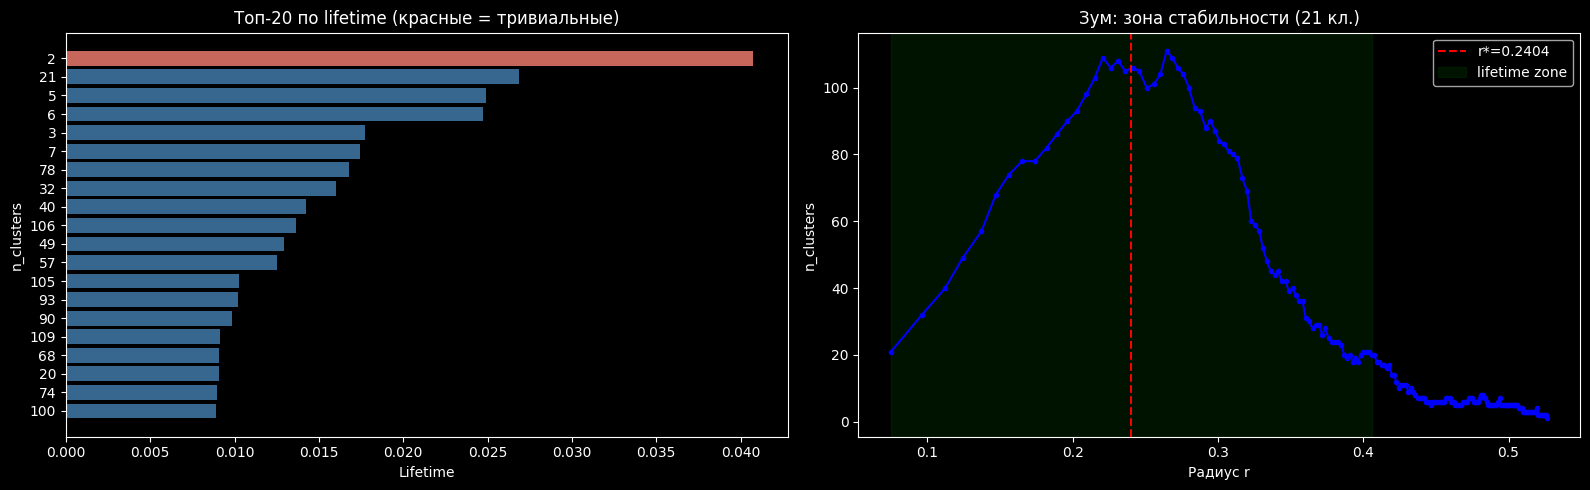

In [33]:
# --- Визуализация lifetime ---
if all_candidates:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Левый: топ-20 по lifetime (все)
    top_ncs = [nc for nc, _ in top_all[:20]]
    top_lts = [all_candidates[nc] for nc in top_ncs]
    colors = ['salmon' if nc < MIN_INTERESTING else 'steelblue' for nc in top_ncs]
    axes[0].barh(range(len(top_ncs)), top_lts,
                 tick_label=[str(n) for n in top_ncs], color=colors, alpha=0.8)
    axes[0].set_xlabel('Lifetime')
    axes[0].set_ylabel('n_clusters')
    axes[0].set_title('Топ-20 по lifetime (красные = тривиальные)')
    axes[0].invert_yaxis()

    # Правый: зум в зону автовыбранного кандидата
    r_lo = best_r_lifetime[0] * 0.7
    r_hi = best_r_lifetime[1] * 1.3
    mask_zoom = (radii >= r_lo) & (radii <= r_hi)
    if mask_zoom.sum() > 2:
        axes[1].plot(radii[mask_zoom], n_cls[mask_zoom], 'b-o', markersize=3)
        axes[1].axvline(r_star_lifetime, color='r', linestyle='--',
                        label=f'r*={r_star_lifetime:.4f}')
        axes[1].axvspan(best_r_lifetime[0], best_r_lifetime[1],
                        alpha=0.15, color='green', label='lifetime zone')
        axes[1].set_xlabel('Радиус r')
        axes[1].set_ylabel('n_clusters')
        axes[1].set_title(f'Зум: зона стабильности ({best_nc_lifetime} кл.)')
        axes[1].legend()

    plt.tight_layout()
    plt.show()


In [34]:
# ============================================================
# Альтернатива: Silhouette scan по нескольким кандидатам радиуса
# (опционально — может быть медленно на 112K точках)
# ============================================================

SILHOUETTE_SCAN = False  # ← поставьте True, если хотите запустить

if SILHOUETTE_SCAN and candidates:
    # Берём несколько кандидатных радиусов из топ lifetime
    candidate_radii = []
    for nc, lt in top_by_lifetime[:5]:
        r_range = lifetime_radii[nc]
        candidate_radii.append((r_range[0] + r_range[1]) / 2)

    # Добавляем несколько промежуточных
    r_min, r_max = radii[radii > 0].min(), radii.max()
    for pct in [0.1, 0.2, 0.3, 0.5, 0.7]:
        candidate_radii.append(r_min + pct * (r_max - r_min))
    candidate_radii = sorted(set(candidate_radii))

    sil_results = []
    for r_cand in candidate_radii:
        w_cand = wishart_clustering(
            X_normed, k=cfg.wishart_k, alpha=cfg.wishart_alpha,
            metric='cosine', final_radius=r_cand,
        )
        mask = w_cand.labels >= 0
        n_cl = len(set(w_cand.labels[mask]))
        if n_cl >= 2 and mask.sum() >= 100:
            sil = silhouette_score(
                X_normed[mask], w_cand.labels[mask],
                metric='cosine', sample_size=min(8000, mask.sum()),
                random_state=42,
            )
        else:
            sil = -1.0
        sil_results.append((r_cand, n_cl, mask.sum(), sil))
        print(f"  r={r_cand:.6f}  clusters={n_cl:5d}  active={mask.sum():6d}  sil={sil:.4f}")

    best_sil = max(sil_results, key=lambda x: x[3])
    print(f"\n→ Best by silhouette: r={best_sil[0]:.6f}, clusters={best_sil[1]}, sil={best_sil[3]:.4f}")

    fig, ax = plt.subplots(figsize=(10, 4))
    rs = [x[0] for x in sil_results]
    ss = [x[3] for x in sil_results]
    ax.plot(rs, ss, 'o-')
    ax.set_xlabel('Радиус')
    ax.set_ylabel('Silhouette')
    ax.set_title('Silhouette scan по радиусу Вишарта')
    plt.tight_layout()
    plt.show()

### 3a.2 Перезапуск Вишарта с выбранным радиусом

In [35]:
# ============================================================
# Перезапуск Вишарта с оптимальным радиусом
# ============================================================
# Выберите один из вариантов:
chosen_radius = r_star_lifetime  # из max-lifetime эвристики
# chosen_radius = best_sil[0]    # из silhouette scan (если запускали)
# chosen_radius = 0.85           # или вручную по графику иерархии

print(f"Перезапуск с final_radius={chosen_radius:.6f}")
print("(kNN уже посчитан — повторный запуск только DSU, быстро)")
print()

# Повторный запуск — но kNN уже в кэше sklearn, а DSU занимает секунды
wishart = wishart_clustering(
    X_normed,
    k=cfg.wishart_k,
    alpha=cfg.wishart_alpha,
    metric="cosine",
    snapshot_every=0,
    final_radius=chosen_radius,
)

unique_labels = set(wishart.labels)
n_clusters_w = len(unique_labels - {-1})
n_noise_w = (wishart.labels == -1).sum()
n_assigned = (wishart.labels >= 0).sum()

print(f"Вишарт (r*={chosen_radius:.4f}):")
print(f"  Кластеров: {n_clusters_w}")
print(f"  Присвоено: {n_assigned} ({100*n_assigned/len(wishart.labels):.1f}%)")
print(f"  Шум (не активировались): {n_noise_w} ({100*n_noise_w/len(wishart.labels):.1f}%)")

# Размеры кластеров
from collections import Counter
label_counts = Counter(wishart.labels[wishart.labels >= 0])
sizes = sorted(label_counts.values(), reverse=True)
print(f"  Топ-10 размеров: {sizes[:10]}")
print(f"  Кластеров с 1 точкой: {sum(1 for s in sizes if s == 1)}")
print(f"  Кластеров ≥10 точек: {sum(1 for s in sizes if s >= 10)}")
print(f"  Кластеров ≥100 точек: {sum(1 for s in sizes if s >= 100)}")

Перезапуск с final_radius=0.240444
(kNN уже посчитан — повторный запуск только DSU, быстро)

Вишарт (r*=0.2404):
  Кластеров: 105
  Присвоено: 6678 (5.9%)
  Шум (не активировались): 106235 (94.1%)
  Топ-10 размеров: [1078, 850, 739, 504, 403, 346, 288, 264, 159, 125]
  Кластеров с 1 точкой: 12
  Кластеров ≥10 точек: 64
  Кластеров ≥100 точек: 11


Кластеров до фильтрации: 77
Размеры: min=5, median=22, mean=86.1, max=1078
Кластеров размера 1: 0
Кластеров размера 2–4: 0
Кластеров размера 5–19: 35
Кластеров размера 20–99: 31
Кластеров размера ≥100: 11


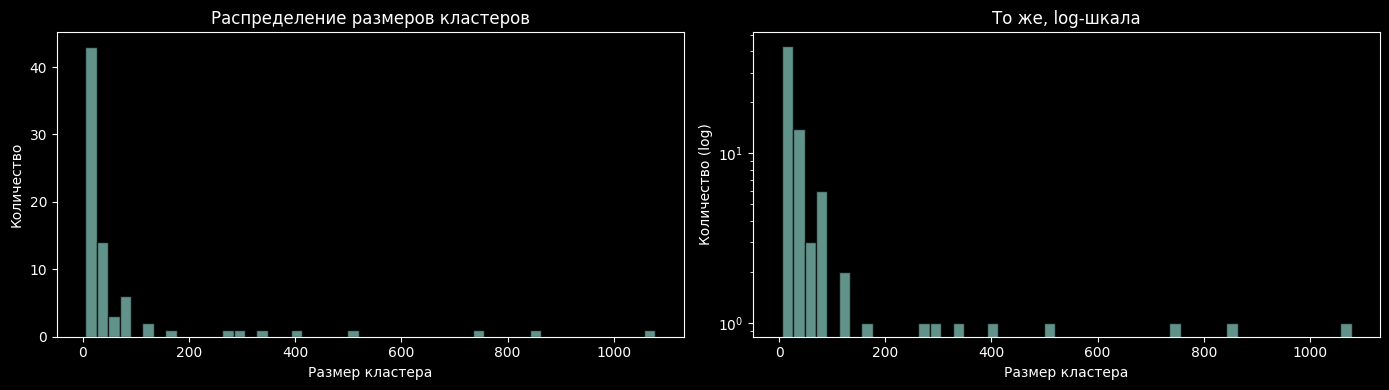

In [37]:
# ============================================================
# Фильтрация кластеров: адаптивный подход
# ============================================================
from collections import Counter

raw_labels = wishart.labels.copy()
label_counts = Counter(raw_labels[raw_labels >= 0])

# --- 1. Распределение размеров кластеров (до фильтрации) ---
sizes_all = sorted(label_counts.values(), reverse=True)
print(f"Кластеров до фильтрации: {len(sizes_all)}")
print(f"Размеры: min={min(sizes_all)}, median={np.median(sizes_all):.0f}, "
      f"mean={np.mean(sizes_all):.1f}, max={max(sizes_all)}")
print(f"Кластеров размера 1: {sum(1 for s in sizes_all if s == 1)}")
print(f"Кластеров размера 2–4: {sum(1 for s in sizes_all if 2 <= s <= 4)}")
print(f"Кластеров размера 5–19: {sum(1 for s in sizes_all if 5 <= s <= 19)}")
print(f"Кластеров размера 20–99: {sum(1 for s in sizes_all if 20 <= s <= 99)}")
print(f"Кластеров размера ≥100: {sum(1 for s in sizes_all if s >= 100)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sizes_all, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Размер кластера")
axes[0].set_ylabel("Количество")
axes[0].set_title("Распределение размеров кластеров")

axes[1].hist(sizes_all, bins=50, edgecolor="black", alpha=0.7, log=True)
axes[1].set_xlabel("Размер кластера")
axes[1].set_ylabel("Количество (log)")
axes[1].set_title("То же, log-шкала")
plt.tight_layout()
plt.show()


  cid    size   tf_med   tf_mean   df_med   df_mean
-------------------------------------------------------
    1    1078      109     304.5       44      72.5
    0     850       64     200.9       38      61.4
    8     739      120     295.9       48      95.5
   17     504      118     275.9       48      89.4
    4     403      147     374.0       47     103.7
   12     346      365     868.1      202     290.5
   14     288      118     237.3       42      69.5
   16     264      167     496.0       36      72.8
   15     159       98     249.7       47      84.8
   27     125      110     203.1       46      76.6
   41     117      172     302.6       52      85.3
   36      90      134     353.7       55     104.3
    6      87       81     313.7       47     119.1
   13      85      139     643.7       71     132.2
    2      78      302     560.8      126     188.1
   35      74      112     379.5       36      71.9
   19      71      103     528.2       50     102.7
   23   

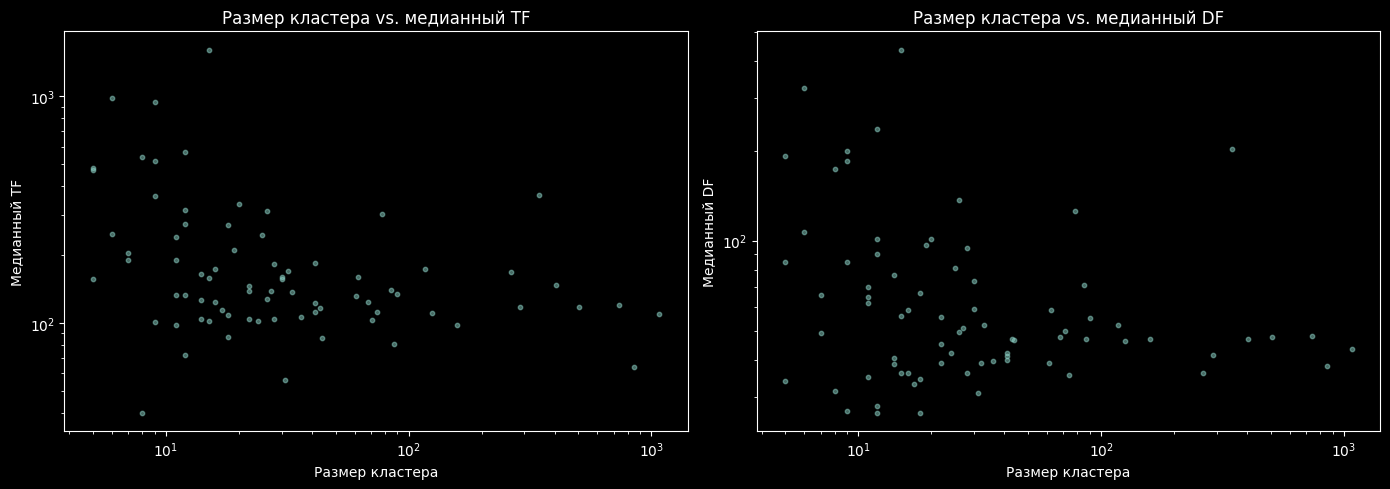

In [38]:
# ============================================================
# Диагностика: TF/DF профиль кластеров
# ============================================================
# Для каждого кластера считаем медианный TF и DF его слов.
# Мусорные кластеры обычно: маленькие + низкий TF + низкий DF.

cluster_profiles = []
for cid, cnt in label_counts.items():
    member_ids = valid_ids[raw_labels == cid]  # глобальные vocab idx
    tfs = vocab_tf[member_ids]
    dfs = vocab_df[member_ids]
    cluster_profiles.append({
        "cid": cid,
        "size": cnt,
        "tf_median": np.median(tfs),
        "tf_mean": np.mean(tfs),
        "df_median": np.median(dfs),
        "df_mean": np.mean(dfs),
    })

profiles = sorted(cluster_profiles, key=lambda x: -x["size"])

print(f"{'cid':>5} {'size':>7} {'tf_med':>8} {'tf_mean':>9} {'df_med':>8} {'df_mean':>9}")
print("-" * 55)
for p in profiles[:30]:
    print(f"{p['cid']:5d} {p['size']:7d} {p['tf_median']:8.0f} "
          f"{p['tf_mean']:9.1f} {p['df_median']:8.0f} {p['df_mean']:9.1f}")
if len(profiles) > 30:
    print(f"... ещё {len(profiles) - 30} кластеров")

# --- Scatter: size vs median TF ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ss = [p["size"] for p in profiles]
tf_meds = [p["tf_median"] for p in profiles]
df_meds = [p["df_median"] for p in profiles]

axes[0].scatter(ss, tf_meds, s=10, alpha=0.5)
axes[0].set_xlabel("Размер кластера")
axes[0].set_ylabel("Медианный TF")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Размер кластера vs. медианный TF")

axes[1].scatter(ss, df_meds, s=10, alpha=0.5)
axes[1].set_xlabel("Размер кластера")
axes[1].set_ylabel("Медианный DF")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Размер кластера vs. медианный DF")
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# Фильтрация кластеров (настрой пороги по графикам выше)
# ============================================================

# Критерии: кластер считается шумом, если ANY из условий:
MIN_CLUSTER_SIZE = 10                # слишком маленький
MIN_MEDIAN_TF_FOR_SMALL = 30        # для кластеров < SMALL_THRESHOLD: мин. медианный TF
SMALL_THRESHOLD = 50                 # что считать "маленьким" кластером

filtered_labels = raw_labels.copy()
noise_reasons: dict[str, int] = {"too_small": 0, "low_tf_small": 0}

for p in cluster_profiles:
    cid = p["cid"]
    is_noise = False

    # Правило 1: слишком маленький кластер
    if p["size"] < MIN_CLUSTER_SIZE:
        is_noise = True
        noise_reasons["too_small"] += p["size"]

    # Правило 2: маленький кластер + низкий TF (вероятно OCR-мусор / hapax)
    elif p["size"] < SMALL_THRESHOLD and p["tf_median"] < MIN_MEDIAN_TF_FOR_SMALL:
        is_noise = True
        noise_reasons["low_tf_small"] += p["size"]

    if is_noise:
        filtered_labels[filtered_labels == cid] = -1

# Перенумеровываем 0..N-1
remaining = sorted(set(filtered_labels) - {-1})
remap = {old: new for new, old in enumerate(remaining)}
wishart_labels_clean = np.array([
    remap[l] if l in remap else -1 for l in filtered_labels
], dtype=int)

n_cl_clean = len(remaining)
n_noise_clean = (wishart_labels_clean == -1).sum()
n_was_noise = (raw_labels == -1).sum()
n_filtered_out = n_noise_clean - n_was_noise

print(f"Фильтрация:")
print(f"  too_small (<{MIN_CLUSTER_SIZE}):         {noise_reasons['too_small']} слов")
print(f"  low_tf + small (<{SMALL_THRESHOLD}, tf_med<{MIN_MEDIAN_TF_FOR_SMALL}): {noise_reasons['low_tf_small']} слов")
print(f"  Итого отфильтровано:          {n_filtered_out} слов")
print()
print(f"Результат:")
print(f"  Кластеров: {n_cl_clean}")
print(f"  Присвоено: {(wishart_labels_clean >= 0).sum()} "
      f"({100*(wishart_labels_clean >= 0).sum()/len(wishart_labels_clean):.1f}%)")
print(f"  Шум: {n_noise_clean} ({100*n_noise_clean/len(wishart_labels_clean):.1f}%)")

# Размеры оставшихся кластеров
clean_counts = Counter(wishart_labels_clean[wishart_labels_clean >= 0])
clean_sizes = sorted(clean_counts.values(), reverse=True)
print(f"  Топ-10 размеров: {clean_sizes[:10]}")

# Применяем
wishart.labels = wishart_labels_clean

Фильтрация:
  too_small (<10):         93 слов
  low_tf + small (<50, tf_med<30): 0 слов
  Итого отфильтровано:          93 слов

Результат:
  Кластеров: 64
  Присвоено: 6534 (5.8%)
  Шум: 106379 (94.2%)
  Топ-10 размеров: [1078, 850, 739, 504, 403, 346, 288, 264, 159, 125]


---
## 3b. DBSCAN (baseline)

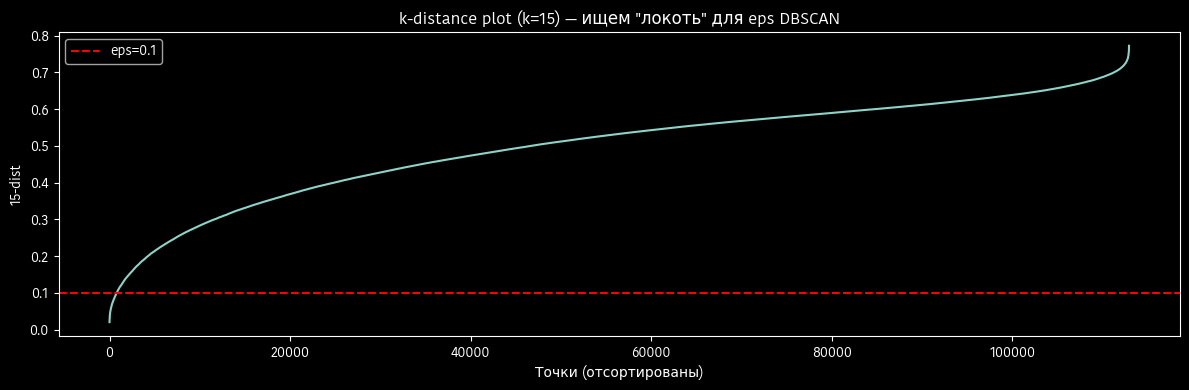

In [65]:
# --- Подбор eps: k-distance plot ---
# Используем knn_dists из Вишарта (или считаем отдельно)
k_dists_sorted = np.sort(wishart.knn_dists)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(k_dists_sorted)
ax.set_ylabel(f'{cfg.wishart_k}-dist')
ax.set_xlabel('Точки (отсортированы)')
ax.set_title(f'k-distance plot (k={cfg.wishart_k}) — ищем "локоть" для eps DBSCAN')
ax.axhline(y=cfg.dbscan_eps, color='r', linestyle='--', label=f'eps={cfg.dbscan_eps}')
ax.legend()
plt.tight_layout()
plt.show()

In [66]:
# --- DBSCAN ---
# ~5–15 мин (radius-поиск brute-force cosine на 112K точках)
dbscan = DBSCAN(
    eps=cfg.dbscan_eps,
    min_samples=cfg.dbscan_min_samples,
    metric='cosine',
)
dbscan_labels = dbscan.fit_predict(X_normed)

n_clusters_d = len(set(dbscan_labels) - {-1})
n_noise_d = (dbscan_labels == -1).sum()
print(f"DBSCAN: {n_clusters_d} кластеров, {n_noise_d} шумовых точек")

DBSCAN: 166 кластеров, 109665 шумовых точек


---
## 4. Валидация кластеризации

Используем внутренние меры (без внешней разметки):
- **Silhouette Score** — [-1, 1], чем больше тем лучше
- **Calinski–Harabasz Index** — чем больше тем лучше
- **Davies–Bouldin Index** — чем меньше тем лучше

In [67]:
core_labels = wishart.labels.copy()
def evaluate_clustering(X: np.ndarray, labels: np.ndarray, name: str):
    """Вычислить и напечатать внутренние меры качества кластеризации."""
    mask = labels >= 0  # исключаем шум
    n_clusters = len(set(labels[mask]))
    n_evaluated = mask.sum()
    n_total = len(labels)
    n_noise = (~mask).sum()

    print(f"[{name}]  evaluated={n_evaluated}/{n_total} ({100*n_evaluated/n_total:.1f}%), "
          f"noise={n_noise} ({100*n_noise/n_total:.1f}%)")

    if n_clusters < 2:
        print(f"[{name}] Менее 2 кластеров — метрики не применимы.")
        return {}

    X_clean = X[mask]
    labels_clean = labels[mask]

    # Для больших данных используем сэмпл для Silhouette
    sample_size = min(10_000, len(X_clean))
    sil = silhouette_score(
        X_clean, labels_clean,
        metric='cosine',
        sample_size=sample_size,
        random_state=42,
    )
    ch = calinski_harabasz_score(X_clean, labels_clean)
    db = davies_bouldin_score(X_clean, labels_clean)

    results = {"silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db,
               "n_evaluated": n_evaluated, "coverage_pct": 100*n_evaluated/n_total}
    print(f"[{name}]  clusters={n_clusters}  "
          f"Silhouette={sil:.4f}  CH={ch:.1f}  DB={db:.4f}")
    return results


# --- Оценка ---
print("=== Wishart (с доназначением) ===")
res_wishart = evaluate_clustering(X_normed, wishart.labels, "Wishart")

print()
print("=== DBSCAN ===")
res_dbscan = evaluate_clustering(X_normed, dbscan_labels, "DBSCAN")

# --- Честное сравнение: Wishart только на ядрах ---
print()
print("=== Wishart (только ядра, без доназначения) ===")
res_wishart_core = evaluate_clustering(X_normed, core_labels, "Wishart-core")


=== Wishart (с доназначением) ===
[Wishart]  evaluated=6534/112913 (5.8%), noise=106379 (94.2%)
[Wishart]  clusters=64  Silhouette=0.3295  CH=66.1  DB=1.5727

=== DBSCAN ===
[DBSCAN]  evaluated=3248/112913 (2.9%), noise=109665 (97.1%)
[DBSCAN]  clusters=166  Silhouette=0.7004  CH=80.6  DB=0.9139

=== Wishart (только ядра, без доназначения) ===
[Wishart-core]  evaluated=6534/112913 (5.8%), noise=106379 (94.2%)
[Wishart-core]  clusters=64  Silhouette=0.3295  CH=66.1  DB=1.5727


---
## 5. Semantic Anchors — опорные векторы кластеров

Из отчёта: *"для каждого кластера находим представителя (центроид или иной устойчивый представитель); считаем этого представителя semantic anchor кластера."*

Реализуем три метода:
- **centroid** — среднее вектров кластера (L2-нормализованное)
- **medoid** — реальная точка, ближайшая к центроиду
- **pagerank** — точка с максимальным personalized PageRank внутри подграфа кластера

In [43]:
@dataclass
class SemanticAnchor:
    """Опорный вектор (anchor) для одного кластера."""
    cluster_id: int
    anchor_idx: int          # индекс в X (локальный, среди valid)
    anchor_global_idx: int   # индекс в исходном vocab
    anchor_word: str
    centroid: np.ndarray
    cluster_size: int
    intra_density: float     # средняя cos-sim внутри кластера к centroid
    top_words: list[str] = field(default_factory=list)  # ближайшие к centroid


def find_semantic_anchors(
    X: np.ndarray,
    labels: np.ndarray,
    valid_ids: np.ndarray,
    id2word: dict[int, str],
    method: str = "medoid",
    top_n: int = 10,
) -> list[SemanticAnchor]:
    """
    Для каждого кластера найти semantic anchor.

    Parameters
    ----------
    X : (n, d) нормализованные векторы
    labels : (n,) метки кластеров (-1 = шум)
    valid_ids : (n,) отображение локальный idx → глобальный vocab idx
    id2word : глобальный словарь
    method : "centroid" | "medoid"
    top_n : сколько ближайших слов к anchor выводить
    """
    anchors = []
    unique = sorted(set(labels) - {-1})

    for cid in unique:
        mask = labels == cid
        cluster_X = X[mask]
        cluster_local_ids = np.where(mask)[0]
        cluster_size = cluster_X.shape[0]

        # Центроид
        centroid = cluster_X.mean(axis=0)
        c_norm = np.linalg.norm(centroid)
        if c_norm > 1e-12:
            centroid /= c_norm

        # Косинусные сходства с центроидом
        sims = cluster_X @ centroid

        if method == "centroid":
            # Ближайшая реальная точка к центроиду (фактически medoid к centroid)
            best_local = np.argmax(sims)
        elif method == "medoid":
            # Точка с максимальным средним сходством к остальным
            if cluster_size <= 200:
                sim_matrix = cluster_X @ cluster_X.T
                mean_sims = sim_matrix.mean(axis=1)
                best_local = np.argmax(mean_sims)
            else:
                # Для больших кластеров — аппроксимация через centroid
                best_local = np.argmax(sims)
        else:
            raise ValueError(f"Unknown method: {method}")

        anchor_local = cluster_local_ids[best_local]
        anchor_global = valid_ids[anchor_local]
        anchor_word = id2word.get(anchor_global, f"<UNK:{anchor_global}>")

        # Top-N ближайших к центроиду
        top_local = np.argsort(-sims)[:top_n]
        top_global_ids = [valid_ids[cluster_local_ids[i]] for i in top_local]
        top_words = [id2word.get(gid, f"<UNK:{gid}>") for gid in top_global_ids]

        intra_density = float(sims.mean())

        anchors.append(SemanticAnchor(
            cluster_id=cid,
            anchor_idx=anchor_local,
            anchor_global_idx=int(anchor_global),
            anchor_word=anchor_word,
            centroid=centroid,
            cluster_size=cluster_size,
            intra_density=intra_density,
            top_words=top_words,
        ))

    return anchors

In [44]:
# --- Нахождение anchors для кластеров Вишарта ---
anchors_wishart = find_semantic_anchors(
    X_normed, wishart.labels, valid_ids, id2word,
    method=cfg.anchor_method,
    top_n=cfg.anchor_top_n,
)

print(f"Найдено {len(anchors_wishart)} semantic anchors\n")
for a in sorted(anchors_wishart, key=lambda x: -x.cluster_size)[:15]:
    print(f"  Cluster {a.cluster_id:3d} | size={a.cluster_size:5d} | "
          f"density={a.intra_density:.3f} | anchor='{a.anchor_word}'")
    print(f"    top words: {a.top_words}")

Найдено 64 semantic anchors

  Cluster   1 | size= 1078 | density=0.387 | anchor='सुचिर'
    top words: ['सुचिर', 'भूवरि', 'कराया', 'तदा', 'तदीय', 'सोडून', 'करितिल', 'म्हणुनि', 'पाहुन', 'पाहुनि']
  Cluster   0 | size=  850 | density=0.520 | anchor='अंगणी'
    top words: ['अंगणी', 'माळ्याच्या', 'भरला', 'मनगटी', 'माळीाचा', 'लेकाच्या', 'शेजी', 'तान्ही', 'रुतती', 'माळीण']
  Cluster   8 | size=  739 | density=0.410 | anchor='सुधी'
    top words: ['सुधी', 'राखी', 'उतारी', 'करव', 'उपर', 'आपव', 'आवे', 'जेवा', 'वखणे', 'घणी']
  Cluster  17 | size=  504 | density=0.396 | anchor='रेक्'
    top words: ['रेक्', 'ह्यापासून', 'वरचा', 'ह्यांवर', 'वरची', 'कामन', 'चपटे', 'खालची', 'खालच्या', 'द्यावर']
  Cluster   4 | size=  403 | density=0.625 | anchor='पीछे'
    top words: ['पीछे', 'किये', 'वह', 'करके', 'देकर', 'उसकी', 'पीछ', 'दिख', 'उसके', 'सामने']
  Cluster  12 | size=  346 | density=0.611 | anchor='निट'
    top words: ['निट', 'टत', 'टण', 'पफ', 'टप', 'रिट', 'हपड', 'पह', 'शिट', 'पड']
  Cluster  14 | siz

Получили разделение по стилям языка
* Кластер 26 - Исторические слова 13-14 веков
* Кластер 1 - Литературные слова, слова классического маратхи 19 века
* Кластер 14 - Админинстративные слова, офицальный стиль
* Клкстер 4 - Хинди

Тематические кластеры
* Кластер 35 - Астрономия
* Кластер 39 - Техника
* Кластер 16 - Грамматика(скорее всего с учебников маратхского языка)

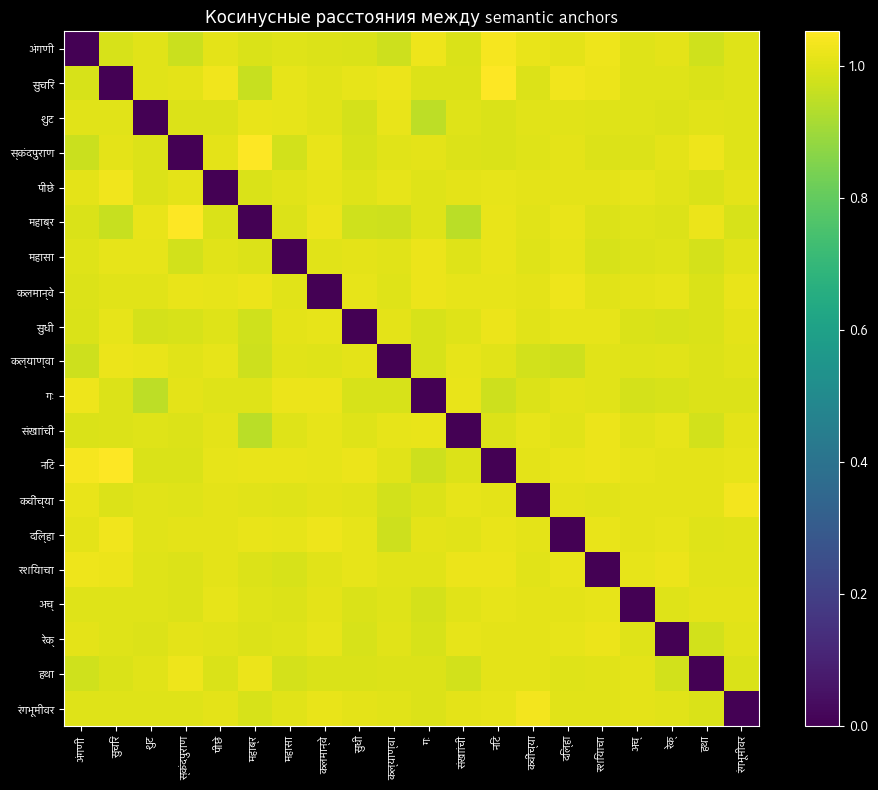

In [47]:
# --- Межкластерные расстояния между anchors ---
if len(anchors_wishart) >= 2:
    anchor_vectors = np.array([a.centroid for a in anchors_wishart])
    anchor_dist_matrix = 1 - anchor_vectors @ anchor_vectors.T  # cosine distance

    n_show = min(20, len(anchors_wishart))
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(anchor_dist_matrix[:n_show, :n_show], cmap='viridis')
    anchor_labels = [a.anchor_word[:12] for a in anchors_wishart[:n_show]]
    ax.set_xticks(range(n_show))
    ax.set_xticklabels(anchor_labels, rotation=90, fontsize=8)
    ax.set_yticks(range(n_show))
    ax.set_yticklabels(anchor_labels, fontsize=8)
    ax.set_title('Косинусные расстояния между semantic anchors')
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

---
## 6. Anchor Words — извлечение anchor-слов

**Anchor words** (в смысле topic modeling) — это слова, характерные *исключительно* для одной темы/кластера.  
Формально: слово $w$ является anchor-словом для кластера $c$, если его распределение
по кластерам сильно сконцентрировано в $c$.

### Алгоритм
1. Для каждого слова $w$ — считаем вектор принадлежности: $p(c|w)$ — степень close-ости к центроиду каждого кластера.
2. Anchor score: насколько $p(c|w)$ "острый" (доминирует один кластер).
3. Anchor words — слова с максимальным anchor score для каждого кластера.

In [48]:
@dataclass
class AnchorWordResult:
    """Результат anchor-word анализа."""
    membership: np.ndarray     # (n_words, n_clusters) — p(c|w)
    anchor_scores: np.ndarray  # (n_words,) — max_c p(c|w), т.е. "чистота"
    dominant_cluster: np.ndarray  # (n_words,) — argmax cluster
    per_cluster_anchors: dict[int, list[tuple[int, str, float]]]  # cid -> [(local_idx, word, score)]


def compute_anchor_words(
    X: np.ndarray,
    anchors: list[SemanticAnchor],
    valid_ids: np.ndarray,
    id2word: dict[int, str],
    top_n: int = 10,
    temperature: float = 5.0,
) -> AnchorWordResult:
    """
    Anchor Words: найти слова, характерные исключительно для одного кластера.

    Для каждого слова w считаем:
      sim(w, c) = cos(x_w, centroid_c)
      p(c|w) = softmax(sim * temperature)
      anchor_score(w) = max_c p(c|w)

    Parameters
    ----------
    X : (n, d) нормализованные векторы
    anchors : список SemanticAnchor
    temperature : температура softmax (больше → "острее" распределение)
    top_n : сколько anchor-слов на кластер
    """
    n = X.shape[0]
    n_clusters = len(anchors)

    # Матрица центроидов: (n_clusters, d)
    centroids = np.array([a.centroid for a in anchors])

    # Сходства: (n_words, n_clusters)
    sim_matrix = X @ centroids.T  # cosine sim (X уже L2-normalized)

    # Softmax с температурой → p(c|w)
    logits = sim_matrix * temperature
    logits -= logits.max(axis=1, keepdims=True)  # numerical stability
    exp_logits = np.exp(logits)
    membership = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    # Anchor score = max_c p(c|w)
    anchor_scores = membership.max(axis=1)
    dominant_cluster = membership.argmax(axis=1)

    # Per-cluster top anchor words
    per_cluster: dict[int, list[tuple[int, str, float]]] = {}
    for c_idx in range(n_clusters):
        cid = anchors[c_idx].cluster_id
        # Слова, доминируемые данным кластером
        c_mask = dominant_cluster == c_idx
        c_indices = np.where(c_mask)[0]

        if len(c_indices) == 0:
            per_cluster[cid] = []
            continue

        c_scores = anchor_scores[c_indices]
        top_local = c_indices[np.argsort(-c_scores)[:top_n]]

        per_cluster[cid] = [
            (
                int(idx),
                id2word.get(int(valid_ids[idx]), f"<UNK:{valid_ids[idx]}>"),
                float(anchor_scores[idx]),
            )
            for idx in top_local
        ]

    return AnchorWordResult(
        membership=membership,
        anchor_scores=anchor_scores,
        dominant_cluster=dominant_cluster,
        per_cluster_anchors=per_cluster,
    )

In [49]:
# --- Запуск anchor words ---
aw_result = compute_anchor_words(
    X_normed, anchors_wishart, valid_ids, id2word,
    top_n=cfg.anchor_top_n,
    temperature=5.0,
)

print(f"Распределение anchor_score:")
print(f"  mean={aw_result.anchor_scores.mean():.4f}  "
      f"median={np.median(aw_result.anchor_scores):.4f}  "
      f"min={aw_result.anchor_scores.min():.4f}  "
      f"max={aw_result.anchor_scores.max():.4f}")

Распределение anchor_score:
  mean=0.0886  median=0.0508  min=0.0181  max=0.7008


In [50]:
# --- Вывод anchor words по кластерам ---
for a in sorted(anchors_wishart, key=lambda x: -x.cluster_size)[:15]:
    cid = a.cluster_id
    aw = aw_result.per_cluster_anchors.get(cid, [])
    words_str = ", ".join(f"{w}({s:.3f})" for _, w, s in aw)
    print(f"\nCluster {cid} (size={a.cluster_size}, anchor='{a.anchor_word}'):")
    print(f"  Anchor words: {words_str}")


Cluster 1 (size=1078, anchor='सुचिर'):
  Anchor words: तूर्ण(0.419), त्वदर्थ(0.357), सुचिर(0.331), तदा(0.327), सोडून(0.320), कराया(0.320), भूवरि(0.316), त्वां(0.312), म्हणुनि(0.311), करितिल(0.310)

Cluster 0 (size=850, anchor='अंगणी'):
  Anchor words: अंगणी(0.638), माळ्याच्या(0.630), भरला(0.627), माळीाचा(0.615), मनगटी(0.612), शेजी(0.581), तान्ही(0.579), लेकाच्या(0.577), माळीण(0.568), रुतती(0.565)

Cluster 8 (size=739, anchor='सुधी'):
  Anchor words: सुधी(0.570), राखी(0.503), करव(0.494), उतारी(0.493), उपर(0.454), आपव(0.446), थवा(0.441), आवे(0.440), घणी(0.440), वखणे(0.436)

Cluster 17 (size=504, anchor='रेक्'):
  Anchor words: रेक्(0.395), ह्यापासून(0.365), संयोगी(0.351), वरचा(0.343), ह्यांवर(0.335), वरची(0.331), शोषक(0.330), लचा(0.316), कामन(0.310), कमानीचा(0.308)

Cluster 4 (size=403, anchor='पीछे'):
  Anchor words: पीछे(0.683), किये(0.650), वह(0.649), करके(0.633), देकर(0.628), उसकी(0.624), पीछ(0.620), उसके(0.615), दिख(0.614), उसका(0.608)

Cluster 12 (size=346, anchor='निट'):
  Anchor

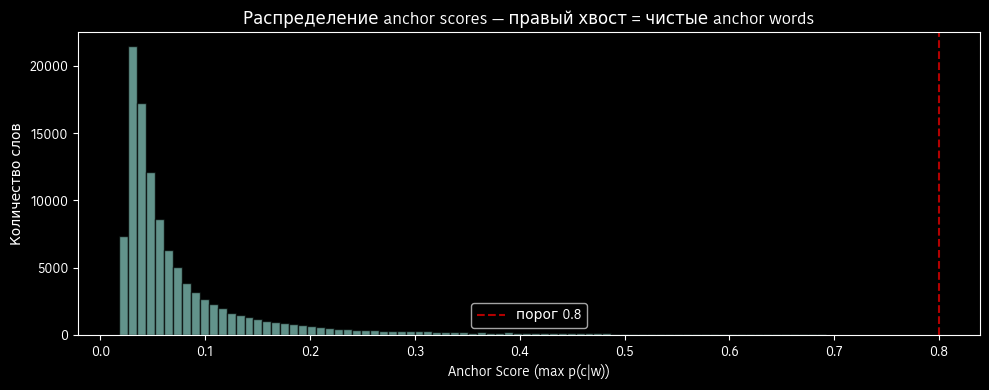

Слов с anchor_score > 0.8: 0 (0.0%)


In [51]:
# --- Гистограмма anchor scores ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(aw_result.anchor_scores, bins=80, edgecolor='black', alpha=0.7)
ax.set_xlabel('Anchor Score (max p(c|w))')
ax.set_ylabel('Количество слов')
ax.set_title('Распределение anchor scores — правый хвост = чистые anchor words')
ax.axvline(x=0.8, color='r', linestyle='--', alpha=0.7, label='порог 0.8')
ax.legend()
plt.tight_layout()
plt.show()

n_strong = (aw_result.anchor_scores > 0.8).sum()
print(f"Слов с anchor_score > 0.8: {n_strong} ({100*n_strong/len(aw_result.anchor_scores):.1f}%)")

---
## 7. Визуализация: PCA 2D + кластеры + anchors

In [52]:
# --- PCA-проекция ---
# ~10–30 сек (PCA на 112K×300)
pca = PCA(n_components=cfg.pca_components, random_state=42)
X_2d = pca.fit_transform(X_normed)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative: {pca.explained_variance_ratio_.sum():.4f}")

Explained variance ratio: [0.03965673 0.01213295]
Cumulative: 0.0518


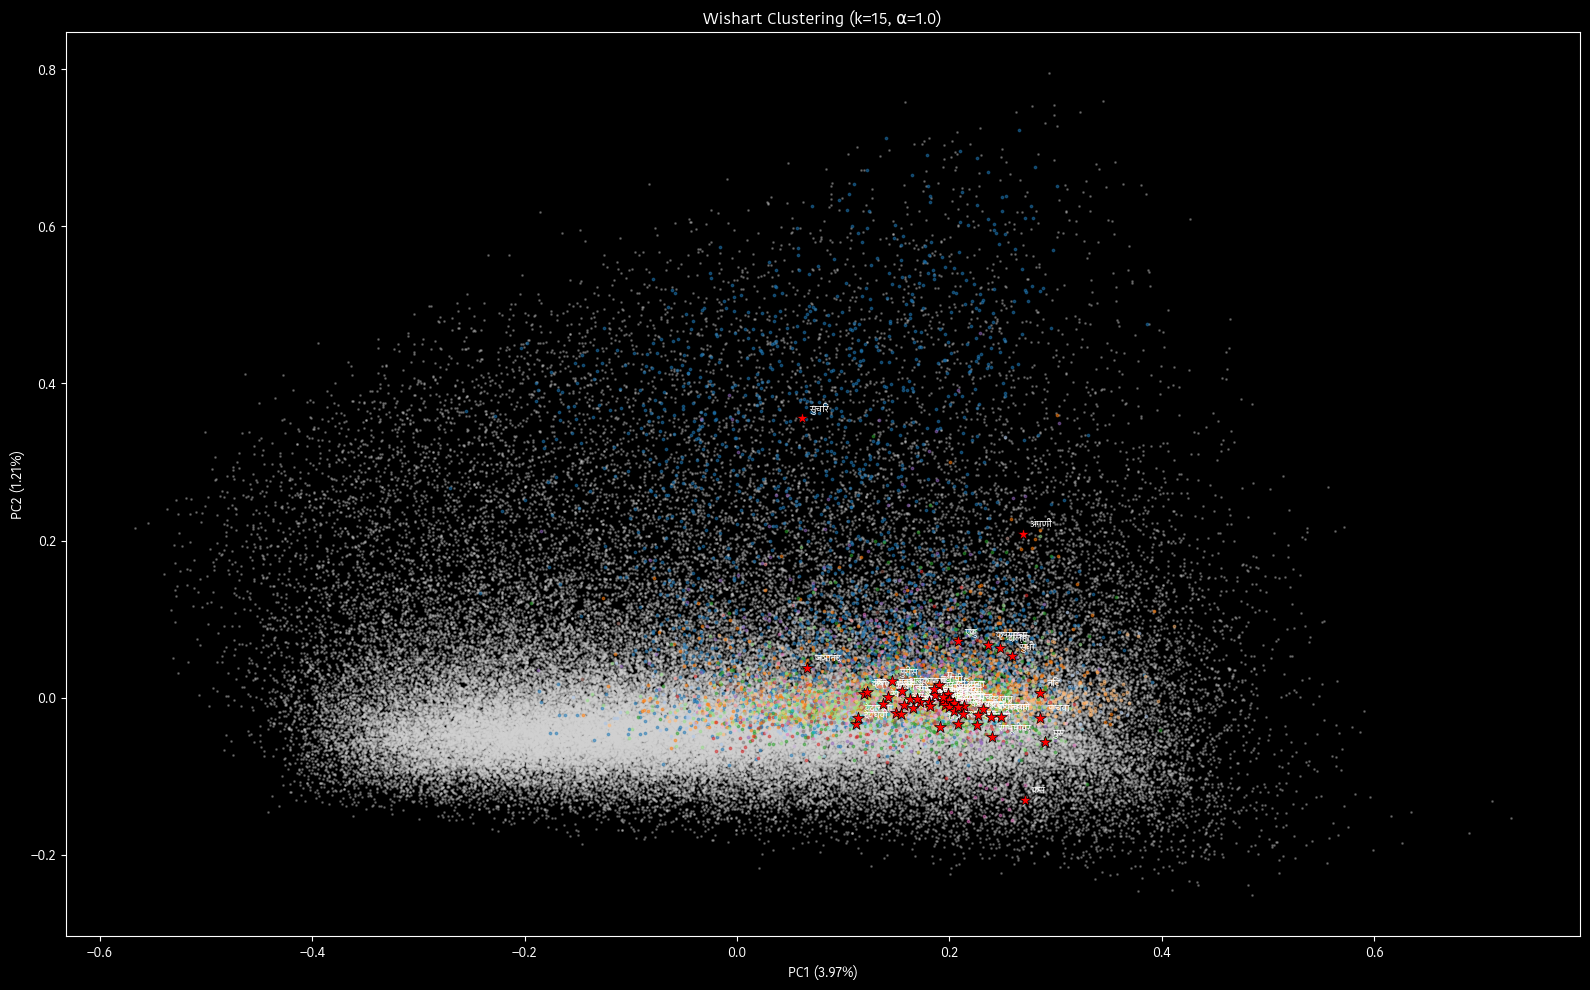

In [53]:
def plot_clusters_with_anchors(
    X_2d: np.ndarray,
    labels: np.ndarray,
    anchors: list[SemanticAnchor],
    title: str = "Clusters + Semantic Anchors",
    max_labels: int = 50,
):
    """PCA scatter: кластеры цветом, anchors крупными маркерами с подписями."""
    fig, ax = plt.subplots(figsize=(16, 10))

    unique_labels = sorted(set(labels) - {-1})
    colors = cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))

    # Шум серым
    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
                   c='lightgray', s=1, alpha=0.3, label='noise')

    # Кластеры
    for i, cid in enumerate(unique_labels):
        mask = labels == cid
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[colors[i % len(colors)]], s=3, alpha=0.5)

    # Anchors
    shown = 0
    for a in sorted(anchors, key=lambda x: -x.cluster_size):
        if shown >= max_labels:
            break
        idx = a.anchor_idx
        ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
                   c='red', s=80, marker='*', edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(
            f"{a.anchor_word}",
            (X_2d[idx, 0], X_2d[idx, 1]),
            fontsize=7, fontweight='bold',
            xytext=(5, 5), textcoords='offset points',
        )
        shown += 1

    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.tight_layout()
    plt.show()


plot_clusters_with_anchors(
    X_2d, wishart.labels, anchors_wishart,
    title=f"Wishart Clustering (k={cfg.wishart_k}, α={cfg.wishart_alpha})",
    max_labels=cfg.max_labels_on_plot,
)

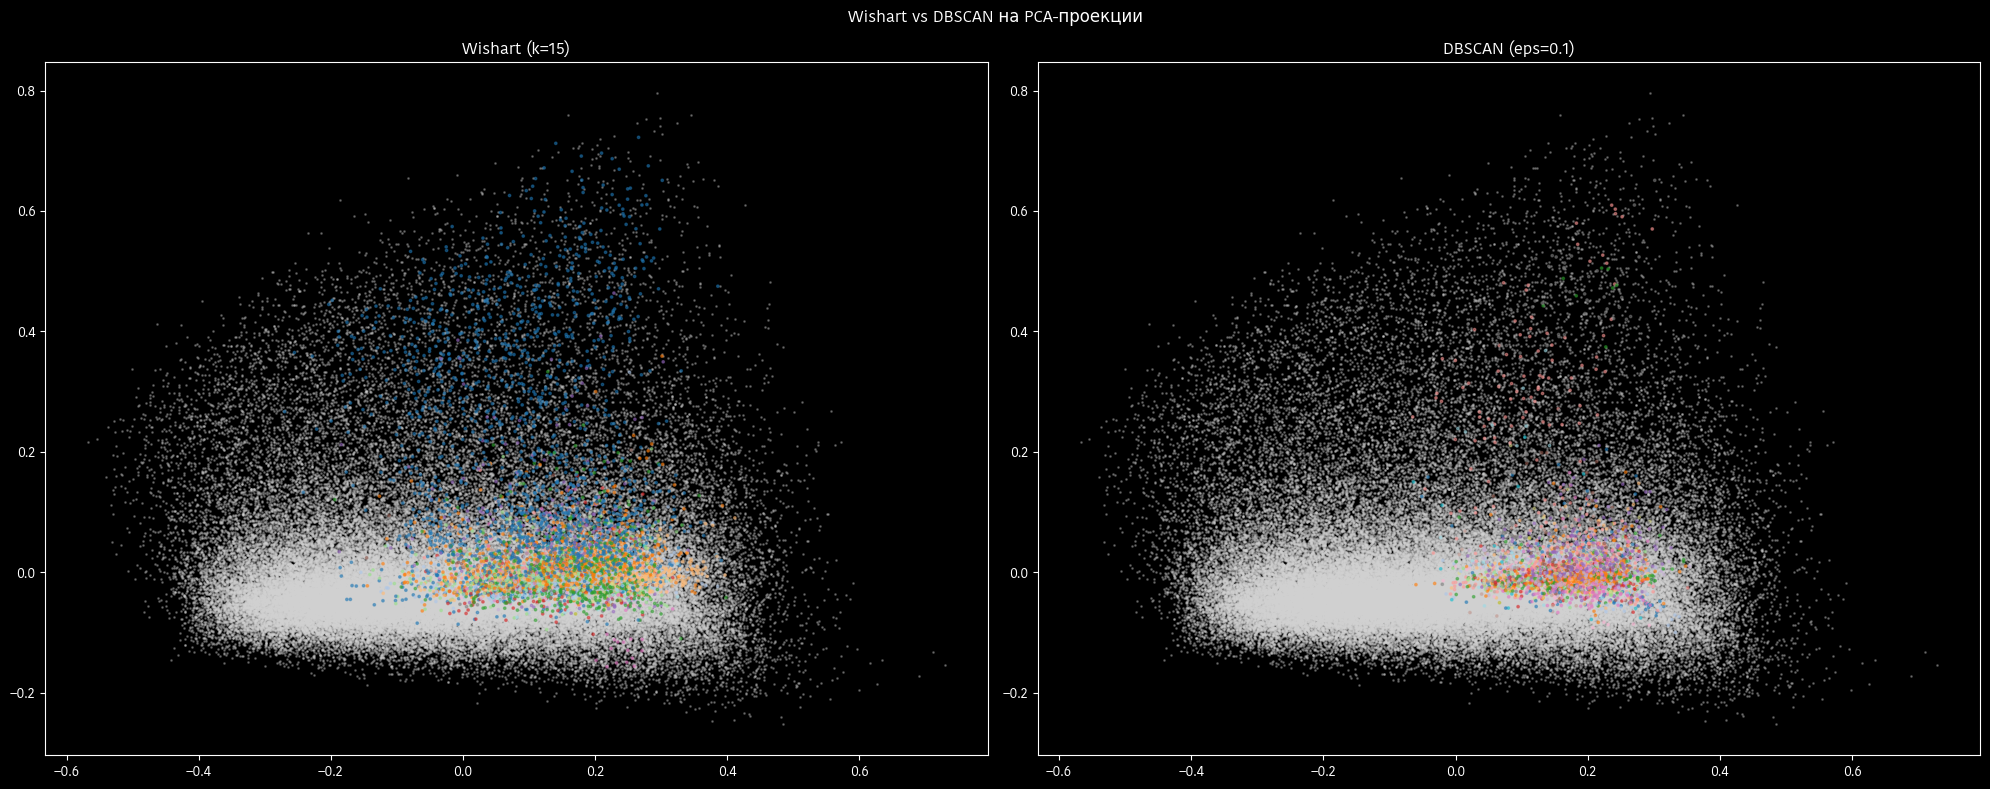

In [68]:
# --- Сравнительная визуализация: Wishart vs DBSCAN ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, labels, title in [
    (axes[0], wishart.labels, f"Wishart (k={cfg.wishart_k})"),
    (axes[1], dbscan_labels, f"DBSCAN (eps={cfg.dbscan_eps})"),
]:
    noise = labels == -1
    ax.scatter(X_2d[noise, 0], X_2d[noise, 1], c='lightgray', s=1, alpha=0.3)
    ax.scatter(X_2d[~noise, 0], X_2d[~noise, 1],
               c=labels[~noise], cmap='tab20', s=3, alpha=0.5)
    ax.set_title(title)

plt.suptitle('Wishart vs DBSCAN на PCA-проекции')
plt.tight_layout()
plt.show()

---
## 8. Утилиты для дальнейших экспериментов

In [ ]:
def query_nearest_to_word(
    word: str,
    X: np.ndarray,
    word2id: dict[str, int],
    id2word: dict[int, str],
    valid_ids: np.ndarray,
    top_k: int = 10,
) -> list[tuple[str, float]]:
    """Найти top_k ближайших слов к заданному слову."""
    if word not in word2id:
        print(f"Слово '{word}' не найдено в словаре.")
        return []
    gid = word2id[word]
    local_candidates = np.where(valid_ids == gid)[0]
    if len(local_candidates) == 0:
        print(f"Слово '{word}' (gid={gid}) имеет нулевой вектор.")
        return []
    local_idx = local_candidates[0]
    sims = X @ X[local_idx]
    top_idx = np.argsort(-sims)[1:top_k + 1]  # исключаем само слово
    return [
        (id2word.get(int(valid_ids[i]), f"<UNK:{valid_ids[i]}>"), float(sims[i]))
        for i in top_idx
    ]


def cluster_summary(anchors: list[SemanticAnchor], aw: AnchorWordResult) -> str:
    """Текстовая сводка по кластерам."""
    lines = []
    for a in sorted(anchors, key=lambda x: -x.cluster_size):
        cid = a.cluster_id
        aw_words = aw.per_cluster_anchors.get(cid, [])
        words_str = ", ".join(w for _, w, _ in aw_words[:5])
        lines.append(
            f"C{cid:03d} | {a.cluster_size:5d} pts | "
            f"density={a.intra_density:.3f} | "
            f"anchor='{a.anchor_word}' | "
            f"keywords: {words_str}"
        )
    return "\n".join(lines)


# Пример использования:
# results = query_nearest_to_word("<СЛОВО>", X_normed, word2id, id2word, valid_ids)
# print(results)

In [ ]:
# --- Полная сводка ---
print(cluster_summary(anchors_wishart, aw_result))

---
## Заметки и TODO

- [ ] Попробовать разные `final_radius` в Вишарте для получения разной гранулярности
- [ ] Реализовать PageRank-метод для поиска anchor: построить kNN-граф подкластера, запустить personalized PageRank
- [ ] Сравнить NMF-кластеризацию с плотностной
- [ ] Нулевая модель: сравнить метрики с рандомным shuffle labels
- [ ] Проверка стабильности: bootstrap на подвыборках корпуса
- [ ] Расстояния между anchors → кросс-лингвальное согласование